In [1]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from torcheval.metrics.functional import mean_squared_error, r2_score
from pycirclize import Circos

sys.path.insert(1, "/".join(os.path.abspath("").split("/")[0:-1]))
import utils

from importlib import reload

reload(utils)

<module 'utils' from '/coc/flash12/cli726/pdisrnn/iclr2026/monkey_nonlinear/utils.py'>

In [2]:
data_dict = pd.read_pickle("data/source_data_array_with_dir_2.pkl")
x = torch.tensor(data_dict["neural"]).to(torch.float32)
vel = torch.tensor(data_dict["vel"]).to(torch.float32)
loc = vel.cumsum(dim=1)
loc_polar = torch.stack(
    [loc.norm(dim=2), torch.atan2(loc[:, :, 1], loc[:, :, 0])], dim=2
)
direction = data_dict["direction"]
n_trials, n_time_bins, n_neurons = x.shape

## For paper

In [6]:
n_components_list = [2, 4]
method_list = ["lrRNN", "LINT", "SMC", "DisRNN", "DisRNN-MLP"]
combination_list = [
    "2_lrRNN",
    "2_LINT",
    "2_DisRNN",
    "2_DisRNN-MLP",
    "4_lrRNN",
    "4_LINT",
    "4_SMC",
    "4_DisRNN",
]
seed_list = np.arange(5)

In [7]:
def translate(combination):
    n_components, method = combination.split("_")

    if n_components == "2":
        n_components = 2
        if method in ["lrRNN", "LINT", "SMC"]:
            n_groups = 1
            group_rank = 2
        else:
            n_groups = 2
            group_rank = 1
    else:
        n_components = 4
        if method in ["lrRNN", "LINT", "SMC"]:
            n_groups = 1
            group_rank = 4
        elif method == "DisRNN":
            n_groups = 2
            group_rank = 2
        elif method == "DisRNN-(4,1)":
            n_groups = 4
            group_rank = 1

    if method == "DisRNN-MLP":
        setup = "MLP"
    elif method == "LINT":
        setup = f"{(n_groups, group_rank)}_LINT"
    elif method == "SMC":
        setup = f"{n_components}"
    else:
        setup = f"{(n_groups, group_rank)}"

    return setup

In [47]:
tag = "conv"
results_file = f"results_{tag}"

idx = 0
df_list = []
for combination in combination_list:
    setup = translate(combination)
    for seed in seed_list:
        try:
            df_temp = pd.read_csv(f"{results_file}/{setup}_{seed}.csv")
        except:
            print(idx, f"{results_file}/{setup}_{seed}.csv not found")
            idx += 1
            continue
        df_temp["combination"] = f"{combination}"
        n_components, method = combination.split("_")
        df_temp["n_components"] = int(n_components)
        df_temp["method"] = method
        df_temp["seed"] = seed
        df_list.append(df_temp)

        idx += 1

df_result = pd.concat(df_list, ignore_index=True)

In [48]:
def plot_chord_diagram(W, r, ax, percentile=99.8, have_labels=True):
    N = W.shape[0]
    sectors = {n: 1 for n in range(N)}

    # Initialize Circos instance for chord diagram plot
    circos = Circos(sectors=sectors, space=0.5)

    W_abs = np.abs(W)
    threshold = np.percentile(W_abs, percentile)
    W_max = np.max(W_abs)

    for i, sector in enumerate(circos.sectors):
        track = sector.add_track((r - 5, r))
        track.axis(
            fc=f"C{i % 10}",
            lw=0,
        )
        if have_labels:
            if (i % 10 == 0) and (i != 185):
                sector.text(sector.name, r=r + 5, size=8)

    for i in range(N):
        for j in range(N):
            if W_abs[i, j] >= threshold:
                w = W[i, j]
                if w > 0:
                    color = "red"
                else:
                    color = "blue"
                lw = (np.abs(w) - threshold) / (W_max - threshold)
                circos.link(
                    (i, 0.25 - lw / 4, 0.25 + lw / 4),
                    (j, 0.75 - lw / 4, 0.75 + lw / 4),
                    direction=1,
                    color=color,
                    alpha=1,
                )

    circos.plotfig(ax=ax)

In [49]:
def plot_chord_diagram(W, r, ax, percentile=99.8, have_labels=True):
    N = W.shape[0]
    sectors = {n: 1 for n in range(N)}

    # Initialize Circos instance for chord diagram plot
    circos = Circos(sectors=sectors, space=0.5)

    W_abs = np.abs(W)
    threshold = np.percentile(W_abs, percentile)
    W_max = np.max(W_abs)

    for i, sector in enumerate(circos.sectors):
        track = sector.add_track((r - 5, r))
        track.axis(
            fc=f"C{i % 10}",
            lw=0,
        )
        if have_labels:
            if (i % 10 == 0) and (i != 185):
                sector.text(sector.name, r=r + 5, size=8)

    for i in range(N):
        for j in range(N):
            if W_abs[i, j] >= threshold:
                w = W[i, j]
                if w > 0:
                    color = "red"
                else:
                    color = "blue"
                lw = (np.abs(w) - threshold) / (W_max - threshold)
                circos.link(
                    (i, 0.25 - lw / 4, 0.25 + lw / 4),
                    (j, 0.75 - lw / 4, 0.75 + lw / 4),
                    direction=1,
                    color=color,
                    alpha=1,
                )

    circos.plotfig(ax=ax)

In [50]:
def plot_chord_diagram_2(
    W, r, ax, pos_percentile=99.5, neg_percentile=99.5, have_labels=True
):
    N = W.shape[0]
    sectors = {n: 1 for n in range(N)}
    circos = Circos(sectors=sectors, space=0.5)

    # 计算正负连接的阈值
    W_pos = W[W > 0]
    W_neg = W[W < 0]
    pos_thresh = np.percentile(W_pos, pos_percentile) if len(W_pos) > 0 else np.inf
    neg_thresh = (
        np.percentile(np.abs(W_neg), neg_percentile) if len(W_neg) > 0 else np.inf
    )

    W_max = np.max(W)
    W_min = np.max(-W)

    # 绘制扇区
    for i, sector in enumerate(circos.sectors):
        track = sector.add_track((r - 5, r))
        track.axis(fc=f"C{i % 10}", lw=0)
        if have_labels:
            if (i % 10 == 0) and (i != 185):
                sector.text(sector.name, r=r + 5, size=8)

    # 绘制连接
    for i in range(N):
        for j in range(N):
            w = W[i, j]
            if w > 0 and w > pos_thresh:
                color = "red"
                lw = (w - pos_thresh) / (W_max - pos_thresh)
            elif w < 0 and abs(w) > neg_thresh:
                color = "blue"
                lw = (abs(w) - neg_thresh) / (W_min - neg_thresh)
            else:
                continue

            circos.link(
                (i, 0.25 - lw / 4, 0.25 + lw / 4),
                (j, 0.75 - lw / 4, 0.75 + lw / 4),
                direction=1,
                color=color,
                alpha=1,
            )

    circos.plotfig(ax=ax)

In [51]:
def reload_model(combination, seed):
    setup = translate(combination)
    n_components, method = combination.split("_")
    n_components = int(n_components)

    n_total_samples = 256
    if method == "DisRNN-MLP":
        encoder = utils.MLPEncoder(
            obs_dim=n_neurons,
            n_components=n_components,
            n_total_samples=n_total_samples,
        )
        decoder = utils.MLPDecoder(
            obs_dim=n_neurons,
            n_components=n_components,
        )
    else:
        encoder = utils.LinearEncoder(
            obs_dim=n_neurons,
            n_components=n_components,
            n_total_samples=n_total_samples,
        )
        decoder = utils.LinearDecoder(
            obs_dim=n_neurons,
            n_components=n_components,
        )

    lit_btcvi = utils.LitBTCVI.load_from_checkpoint(
        f"{results_file}/{setup}_{seed}.ckpt", encoder=encoder, decoder=decoder
    )
    A = lit_btcvi.decoder.linear.weight.detach().cpu().numpy()
    B = lit_btcvi.encoder.linear.weight.detach().cpu().numpy()
    return A, B

In [52]:
combination_list

['2_lrRNN',
 '2_LINT',
 '2_DisRNN',
 '2_DisRNN-MLP',
 '4_lrRNN',
 '4_LINT',
 '4_SMC',
 '4_DisRNN']

/tmp/ipykernel_197824/3840685298.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  z_aligned = torch.load(f"{results_file}/{setup}_{seed}_z_aligned.pt").reshape(


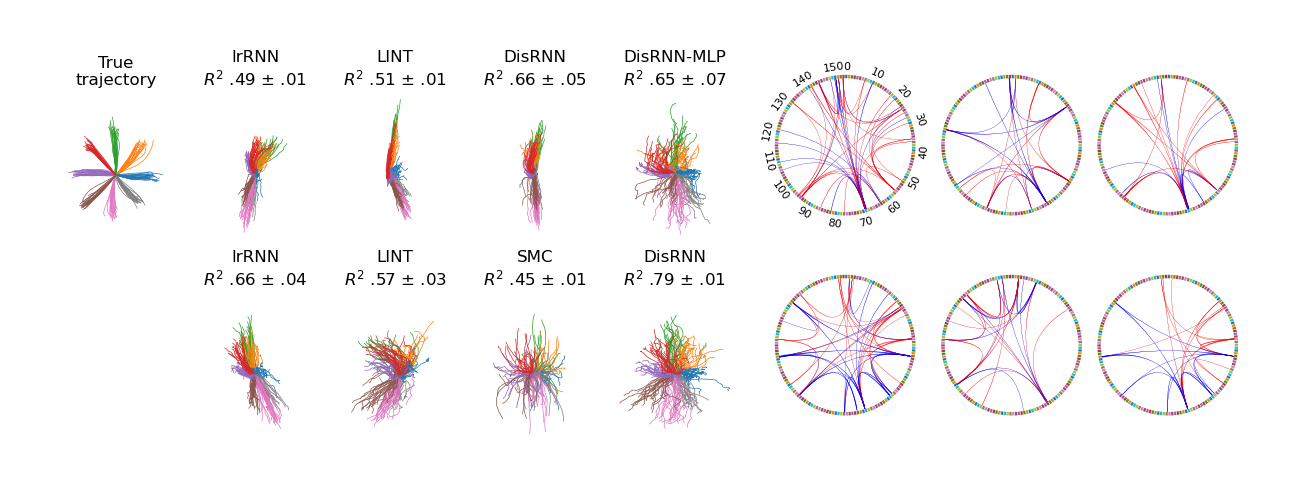

In [41]:
tag = "conv"
results_file = f"results_{tag}"
seed = 4

fig = plt.figure(figsize=(12, 4), layout="constrained")
subfigs = fig.subfigures(1, 2, width_ratios=[1, 0.7])

axs = subfigs[0].subplots(2, 5, sharex=True, sharey=True)

ax = axs[0, 0]
for trial in range(n_trials):
    ax.plot(
        loc[trial, :, 0],
        loc[trial, :, 1],
        c=f"C{direction[trial]}",
    )
ax.set(
    title="True\ntrajectory",
    aspect="equal",
)
ax.axis("off")
for combination, ax in zip(combination_list, axs[:, 1:].flatten()):
    setup = translate(combination)
    n_components, method = combination.split("_")
    n_components = int(n_components)

    if setup == "4":
        seed = 1
    else:
        seed = 4
    z_aligned = torch.load(f"{results_file}/{setup}_{seed}_z_aligned.pt").reshape(
        n_trials, n_time_bins, -1
    )

    for trial in range(n_trials):
        ax.plot(
            z_aligned[trial, :, 0],
            z_aligned[trial, :, 1],
            c=f"C{direction[trial]}",
            linewidth=0.5,
        )
    r2_list = df_result[(df_result["combination"] == f"{combination}")][
        "latent $R^2$"
    ].values
    r2_mean = f"{r2_list.mean():.2f}".lstrip("0")
    r2_se = f"{r2_list.std() / np.sqrt(5):.2f}".lstrip("0")
    ax.set(
        title=f"{method}\n$R^2$ {r2_mean} ± {r2_se}",
        aspect="equal",
    )
    ax.axis("off")
axs[1, 0].axis("off")

seed = 0
axs = subfigs[1].subplots(2, 3, subplot_kw={"projection": "polar"}).flatten()

A, B = reload_model("2_DisRNN", 0)
plot_chord_diagram_2(A @ B, 100, axs[0], 99.8, 99.8, True)
plot_chord_diagram_2(A[:, :1] @ B[:1, :], 100, axs[1], 99.9, 99.9, False)
plot_chord_diagram_2(A[:, 1:] @ B[1:, :], 100, axs[2], 99.9, 99.9, False)

A, B = reload_model("4_DisRNN", 0)
plot_chord_diagram_2(A @ B, 100, axs[3], 99.8, 99.8, False)
plot_chord_diagram_2(A[:, 2:] @ B[2:, :], 100, axs[5], 99.9, 99.9, False)
plot_chord_diagram_2(A[:, :2] @ B[:2, :], 100, axs[4], 99.9, 99.9, False)

fig.savefig("monkey.pdf", transparent=True)

In [9]:
tag = "conv"
results_file = f"results_{tag}"

idx = 0
df_list = []
for combination in combination_list:
    setup = translate(combination)
    for seed in seed_list:
        try:
            df_temp = pd.read_csv(f"{results_file}/{setup}_{seed}_rotation.csv")
        except:
            print(idx, f"{results_file}/{setup}_{seed}.csv not found")
            idx += 1
            continue
        df_temp["combination"] = f"{combination}"
        n_components, method = combination.split("_")
        df_temp["n_components"] = int(n_components)
        df_temp["method"] = method
        df_temp["seed"] = seed
        df_list.append(df_temp)

        idx += 1

df_rotation = pd.concat(df_list, ignore_index=True)

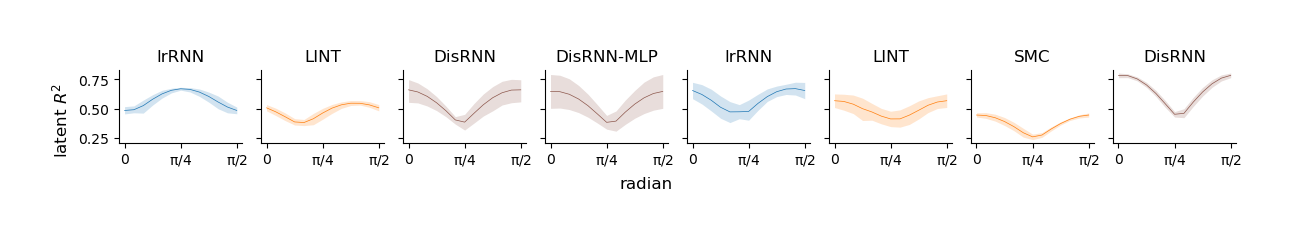

In [12]:
tag = "conv"
results_file = f"results_{tag}"

fig, axs = plt.subplots(
    1, 8, figsize=(12, 1.5), layout="constrained", sharex=True, sharey=True
)
for idx, combination, ax in zip(range(8), combination_list, axs.flatten()):
    n_components, method = combination.split("_")
    n_components = int(n_components)

    sns.lineplot(
        x="radian",
        y="latent $R^2$",
        ax=ax,
        data=df_rotation[df_rotation["combination"] == f"{combination}"],
        color=["C0", "C1", "C5", "C5", "C0", "C1", "C1", "C5"][idx],
    )
    ax.set(
        # title=f"$K = {n_components}$, {method}",
        title=f"{method}",
        xticks=[0, np.pi / 4, np.pi / 2],
        xticklabels=["$0$", "$\\mathrm{\\pi}/4$", "$\\mathrm{\\pi}/2$"],
        xlabel=None,
        ylabel=None,
    )
    sns.despine(ax=ax)
fig.supxlabel("radian")
fig.supylabel("latent $R^2$")
fig.savefig("monkey_rot.pdf", transparent=True)